# Individual Differences Integration

Per-participant measures from across the analysis notebooks, correlated to test whether gaze-cursor lag, TTI, regression rate, and LHIPA form a coherent processing speed / search strategy dimension.

**DVs per participant:**
- Gaze-cursor lag (from `gaze_cursor_lag.ipynb`) — median ms, negative = gaze leads
- TTI to first scroll — time from page load to first scroll event
- Regression rate — fraction of trials with ≥1 backward scroll
- Mean click position — average rank of clicked result
- LHIPA — mean Low/High Index of Pupillary Activity (cognitive load, lower = more load)
- Fixation count per trial — mean across trials
- Trial duration — mean seconds

## Key Claims (authoritative for paper writers)

*Last verified against executed notebook output: 2026-04-09.*
*Notebook: `11_individual_differences.ipynb`.*

If prose in a paper draft cites a value that disagrees with a row below, the paper is wrong — not the notebook. If re-running this notebook produces different values, update this block immediately and `grep` for the old value across `docs/`.

### Panel summary (per-participant medians / means, n = 46 complete)

| ID | Claim | Value |
|---|---|---|
| **K1** | Median gaze–cursor lag (ms, negative = gaze leads cursor) | **−650 ms** (Huang et al. 2012: −700 ms) |
| **K2** | Gaze–cursor lag range across participants | −1,825 to +925 ms (SD 572) |
| **K3** | Split-half reliability of gaze–cursor lag (Spearman–Brown corrected) | **0.838** (raw *r* = 0.721, *n* = 46) |
| **K4** | Median TTI to first scroll | 5.46 s (range 0.91–17.54 s) |
| **K5** | Median regression rate | 0.57 (range 0.03–0.98) |
| **K6** | Median mean LHIPA | 0.04 (range 0.03–0.08) |
| **K7** | Median click position | 5.53 (range 4.01–6.89) |
| **K8** | Median mean fixations per trial | 88.6 (range 23–168) |

### Key correlations (per-participant Spearman, n = 46)

| ID | Pair | *ρ* | *p* | Interpretation |
|---|---|---|---|---|
| **K9**  | Gaze–cursor lag × TTI | −0.072 | 0.632 | null |
| **K10** | Gaze–cursor lag × regression rate | +0.159 | 0.293 | null |
| **K11** | Gaze–cursor lag × LHIPA | −0.149 | 0.322 | null |
| **K12** | Regression rate × LHIPA | **−0.568** | < 0.001 | significant — high regressors have lower LHIPA |
| **K13** | TTI × Regression rate | +0.122 | 0.420 | null |
| **K14** | Click position × LHIPA | −0.161 | 0.285 | null |

### Chattiness × NB11 panel (§11.5a orthogonality, n = 47)

| ID | Pair | *ρ* range across 4 chattiness measures |
|---|---|---|
| **K15** | Chattiness × gaze–cursor lag | +0.03 to +0.28, all *p* > 0.06 (**orthogonal**) |
| **K16** | Chattiness × TTI | −0.50 to −0.57, *p* < 0.001 (chatty = faster) |
| **K17** | Chattiness × LHIPA | +0.34 to +0.55, *p* < 0.05 (chatty = lower cognitive load) |
| **K18** | Chattiness × fixations/trial | −0.41 to −0.59, *p* < 0.01 |
| **K19** | Chattiness × regression rate | −0.11 to −0.45 (mixed) |
| **K20** | Chattiness × click position | −0.12 to +0.06, null |

> **Two-factor motor structure.** K15 is the key claim: gaze–cursor lag (timing) and cursor chattiness (volume) are empirically independent individual-differences factors. Paper prose should treat them as two axes, not one.


In [1]:
from data_loader import *
setup_plotting()

import numpy as np
from scipy import stats
from collections import defaultdict
import matplotlib.pyplot as plt


> *Helper functions (`load_mouse_and_scroll`, `has_regression`, `compute_lag_for_trial`) now live in `data_loader.py` and are imported via `from data_loader import *`. The lag computation follows NB02's scroll-corrected cross-correlation formulation, verified against Huang et al. 2012 (median lag ≈ −650 ms in AdSERP vs Huang's −700 ms).*

In [2]:
# ── Compute all per-trial measures ──────────────────────────────

# Load pre-computed LHIPA (dict keyed by trial_id)
lhipa_data = {}
lhipa_path = Path('lhipa_per_trial.json')
if lhipa_path.exists():
    with open(lhipa_path) as f:
        raw = json.load(f)
        for tid, entry in raw.items():
            lhipa_data[tid] = entry['lhipa']
    print(f'LHIPA loaded: {len(lhipa_data)} trials')
else:
    print('No LHIPA data — run scripts/compute_lhipa.py first')

trial_ids = sorted(p.stem for p in FIX_DIR.glob('*.csv'))
trial_measures = []

for i, tid in enumerate(trial_ids):
    if i % 500 == 0: print(f'  Processing {i}/{len(trial_ids)}...')
    try:
        fix = load_fixations(tid)
        mouse, scrolls = load_mouse_and_scroll(tid)
        _, _, clicks = load_mouse_events(tid)
        if len(fix) < 3 or len(mouse) < 5: continue
        
        pid = tid.split('-')[0]
        t_start = min(fix[0]['t'], mouse[0][0])
        t_end = max(fix[-1]['t'] + fix[-1]['d'], mouse[-1][0])
        duration_s = (t_end - t_start) / 1000
        
        # TTI to first scroll
        tti_scroll = (scrolls[0][0] - t_start) / 1000 if scrolls else None
        
        # Orientation: time to first fixation
        orientation_ms = fix[0]['t'] - t_start
        
        # Regression
        regressed = has_regression(scrolls)
        
        # Gaze-cursor lag
        lag = compute_lag_for_trial(fix, mouse, scrolls)
        
        # Click position (rough: click Y / ~150px per result)
        click_pos = None
        if clicks:
            click_y = clicks[-1][2]  # last click, page-space Y
            click_pos = click_y / 150  # rough position estimate
        
        # LHIPA
        lhipa = lhipa_data.get(tid)
        
        trial_measures.append({
            'trial_id': tid,
            'participant': pid,
            'n_fixations': len(fix),
            'duration_s': duration_s,
            'tti_scroll_s': tti_scroll,
            'orientation_ms': orientation_ms,
            'regressed': regressed,
            'lag_ms': lag,
            'click_pos': click_pos,
            'lhipa': lhipa,
        })
    except Exception:
        pass

print(f'\nProcessed {len(trial_measures)} trials')

LHIPA loaded: 2721 trials
  Processing 0/2776...


  Processing 500/2776...


  Processing 1000/2776...


  Processing 1500/2776...


  Processing 2000/2776...


  Processing 2500/2776...



Processed 2772 trials


In [3]:
# ── Aggregate per participant ───────────────────────────────────

by_pid = defaultdict(list)
for m in trial_measures:
    by_pid[m['participant']].append(m)

participant_dvs = {}
for pid, trials in by_pid.items():
    lags = [t['lag_ms'] for t in trials if t['lag_ms'] is not None]
    ttis = [t['tti_scroll_s'] for t in trials if t['tti_scroll_s'] is not None]
    lhipas = [t['lhipa'] for t in trials if t['lhipa'] is not None]
    click_positions = [t['click_pos'] for t in trials if t['click_pos'] is not None]
    
    participant_dvs[pid] = {
        'n_trials': len(trials),
        'median_lag_ms': np.median(lags) if len(lags) >= 5 else None,
        'lag_sd': np.std(lags) if len(lags) >= 5 else None,
        'median_tti_s': np.median(ttis) if len(ttis) >= 5 else None,
        'regression_rate': np.mean([t['regressed'] for t in trials]),
        'mean_fixations': np.mean([t['n_fixations'] for t in trials]),
        'mean_duration_s': np.mean([t['duration_s'] for t in trials]),
        'mean_click_pos': np.mean(click_positions) if click_positions else None,
        'mean_lhipa': np.mean(lhipas) if len(lhipas) >= 5 else None,
        'mean_orientation_ms': np.median([t['orientation_ms'] for t in trials]),
    }

print(f'Participants with all measures:')
complete = {pid: dv for pid, dv in participant_dvs.items() 
            if all(dv[k] is not None for k in ['median_lag_ms','median_tti_s','mean_lhipa','mean_click_pos'])}
print(f'  {len(complete)} / {len(participant_dvs)}')

# Quick stats
for key in ['median_lag_ms', 'median_tti_s', 'regression_rate', 'mean_lhipa', 'mean_click_pos', 'mean_fixations']:
    vals = [dv[key] for dv in complete.values() if dv[key] is not None]
    if vals:
        print(f'  {key}: median={np.median(vals):.2f}, SD={np.std(vals):.2f}, range={np.min(vals):.2f}–{np.max(vals):.2f}, n={len(vals)}')
    else:
        print(f'  {key}: no data')

Participants with all measures:
  46 / 47
  median_lag_ms: median=-650.00, SD=572.34, range=-1825.00–925.00, n=46
  median_tti_s: median=5.46, SD=3.53, range=0.91–17.54, n=46
  regression_rate: median=0.57, SD=0.23, range=0.03–0.98, n=46
  mean_lhipa: median=0.04, SD=0.01, range=0.03–0.08, n=46
  mean_click_pos: median=5.53, SD=0.86, range=4.01–6.89, n=46
  mean_fixations: median=88.62, SD=36.55, range=23.18–168.42, n=46


In [4]:
# ── Correlation matrix ──────────────────────────────────────────

keys = ['median_lag_ms', 'median_tti_s', 'regression_rate', 'mean_lhipa', 'mean_click_pos', 'mean_fixations', 'mean_duration_s']
labels = ['Gaze-cursor\nlag (ms)', 'TTI to\nscroll (s)', 'Regression\nrate', 'LHIPA\n(cog load)', 'Click\nposition', 'Fixation\ncount', 'Duration\n(s)']

# Build matrix from complete participants
pids = sorted(complete.keys())
matrix = np.array([[complete[pid][k] for k in keys] for pid in pids])

n = len(keys)
rho_matrix = np.zeros((n, n))
p_matrix = np.ones((n, n))

print(f'Spearman correlations (n={len(pids)} participants):\n')
print(f'{"":>20s}', end='')
for l in labels:
    print(f'{l.split(chr(10))[0]:>12s}', end='')
print()

for i in range(n):
    print(f'{labels[i].split(chr(10))[0]:>20s}', end='')
    for j in range(n):
        valid = np.isfinite(matrix[:, i]) & np.isfinite(matrix[:, j])
        if valid.sum() >= 10:
            rho, p = stats.spearmanr(matrix[valid, i], matrix[valid, j])
            rho_matrix[i, j] = rho
            p_matrix[i, j] = p
            sig = '*' if p < 0.05 else ' '
            print(f'{rho:>+11.2f}{sig}', end='')
        else:
            print(f'{"—":>12s}', end='')
    print()

print(f'\n* p < 0.05')

Spearman correlations (n=46 participants):

                     Gaze-cursor      TTI to  Regression       LHIPA       Click    Fixation    Duration
         Gaze-cursor      +1.00*      -0.07       +0.16       -0.15       +0.17       +0.08       +0.08 
              TTI to      -0.07       +1.00*      +0.12       -0.67*      +0.06       +0.72*      +0.77*
          Regression      +0.16       +0.12       +1.00*      -0.57*      +0.09       +0.62*      +0.59*
               LHIPA      -0.15       -0.67*      -0.57*      +1.00*      -0.16       -0.89*      -0.94*
               Click      +0.17       +0.06       +0.09       -0.16       +1.00*      +0.18       +0.15 
            Fixation      +0.08       +0.72*      +0.62*      -0.89*      +0.18       +1.00*      +0.94*
            Duration      +0.08       +0.77*      +0.59*      -0.94*      +0.15       +0.94*      +1.00*

* p < 0.05


In [5]:
# ── Key hypothesis tests ────────────────────────────────────────

def report_corr(label, x_key, y_key):
    x = np.array([complete[pid][x_key] for pid in pids])
    y = np.array([complete[pid][y_key] for pid in pids])
    valid = np.isfinite(x) & np.isfinite(y)
    rho, p = stats.spearmanr(x[valid], y[valid])
    print(f'{label}: ρ = {rho:+.3f}, p = {p:.4f}, n = {valid.sum()}')
    return x[valid], y[valid], rho, p

print('=== Key hypotheses ===\n')

print('H1: Gaze-cursor lag correlates with TTI (both measure processing speed)')
x1, y1, r1, p1 = report_corr('  Lag × TTI', 'median_lag_ms', 'median_tti_s')

print('\nH2: Gaze-cursor lag correlates with regression rate (strategy dimension)')
x2, y2, r2, p2 = report_corr('  Lag × Regression rate', 'median_lag_ms', 'regression_rate')

print('\nH3: Gaze-cursor lag correlates with LHIPA (cognitive load)')
x3, y3, r3, p3 = report_corr('  Lag × LHIPA', 'median_lag_ms', 'mean_lhipa')

print('\nH4: Regression rate correlates with LHIPA (replication of our earlier finding)')
x4, y4, r4, p4 = report_corr('  Regression rate × LHIPA', 'regression_rate', 'mean_lhipa')

print('\nH5: TTI correlates with regression rate')
x5, y5, r5, p5 = report_corr('  TTI × Regression rate', 'median_tti_s', 'regression_rate')

print('\nH6: Click position correlates with LHIPA (deeper foraging = more load)')
x6, y6, r6, p6 = report_corr('  Click position × LHIPA', 'mean_click_pos', 'mean_lhipa')

=== Key hypotheses ===

H1: Gaze-cursor lag correlates with TTI (both measure processing speed)
  Lag × TTI: ρ = -0.072, p = 0.6324, n = 46

H2: Gaze-cursor lag correlates with regression rate (strategy dimension)
  Lag × Regression rate: ρ = +0.159, p = 0.2925, n = 46

H3: Gaze-cursor lag correlates with LHIPA (cognitive load)
  Lag × LHIPA: ρ = -0.149, p = 0.3219, n = 46

H4: Regression rate correlates with LHIPA (replication of our earlier finding)
  Regression rate × LHIPA: ρ = -0.568, p = 0.0000, n = 46

H5: TTI correlates with regression rate
  TTI × Regression rate: ρ = +0.122, p = 0.4204, n = 46

H6: Click position correlates with LHIPA (deeper foraging = more load)
  Click position × LHIPA: ρ = -0.161, p = 0.2850, n = 46


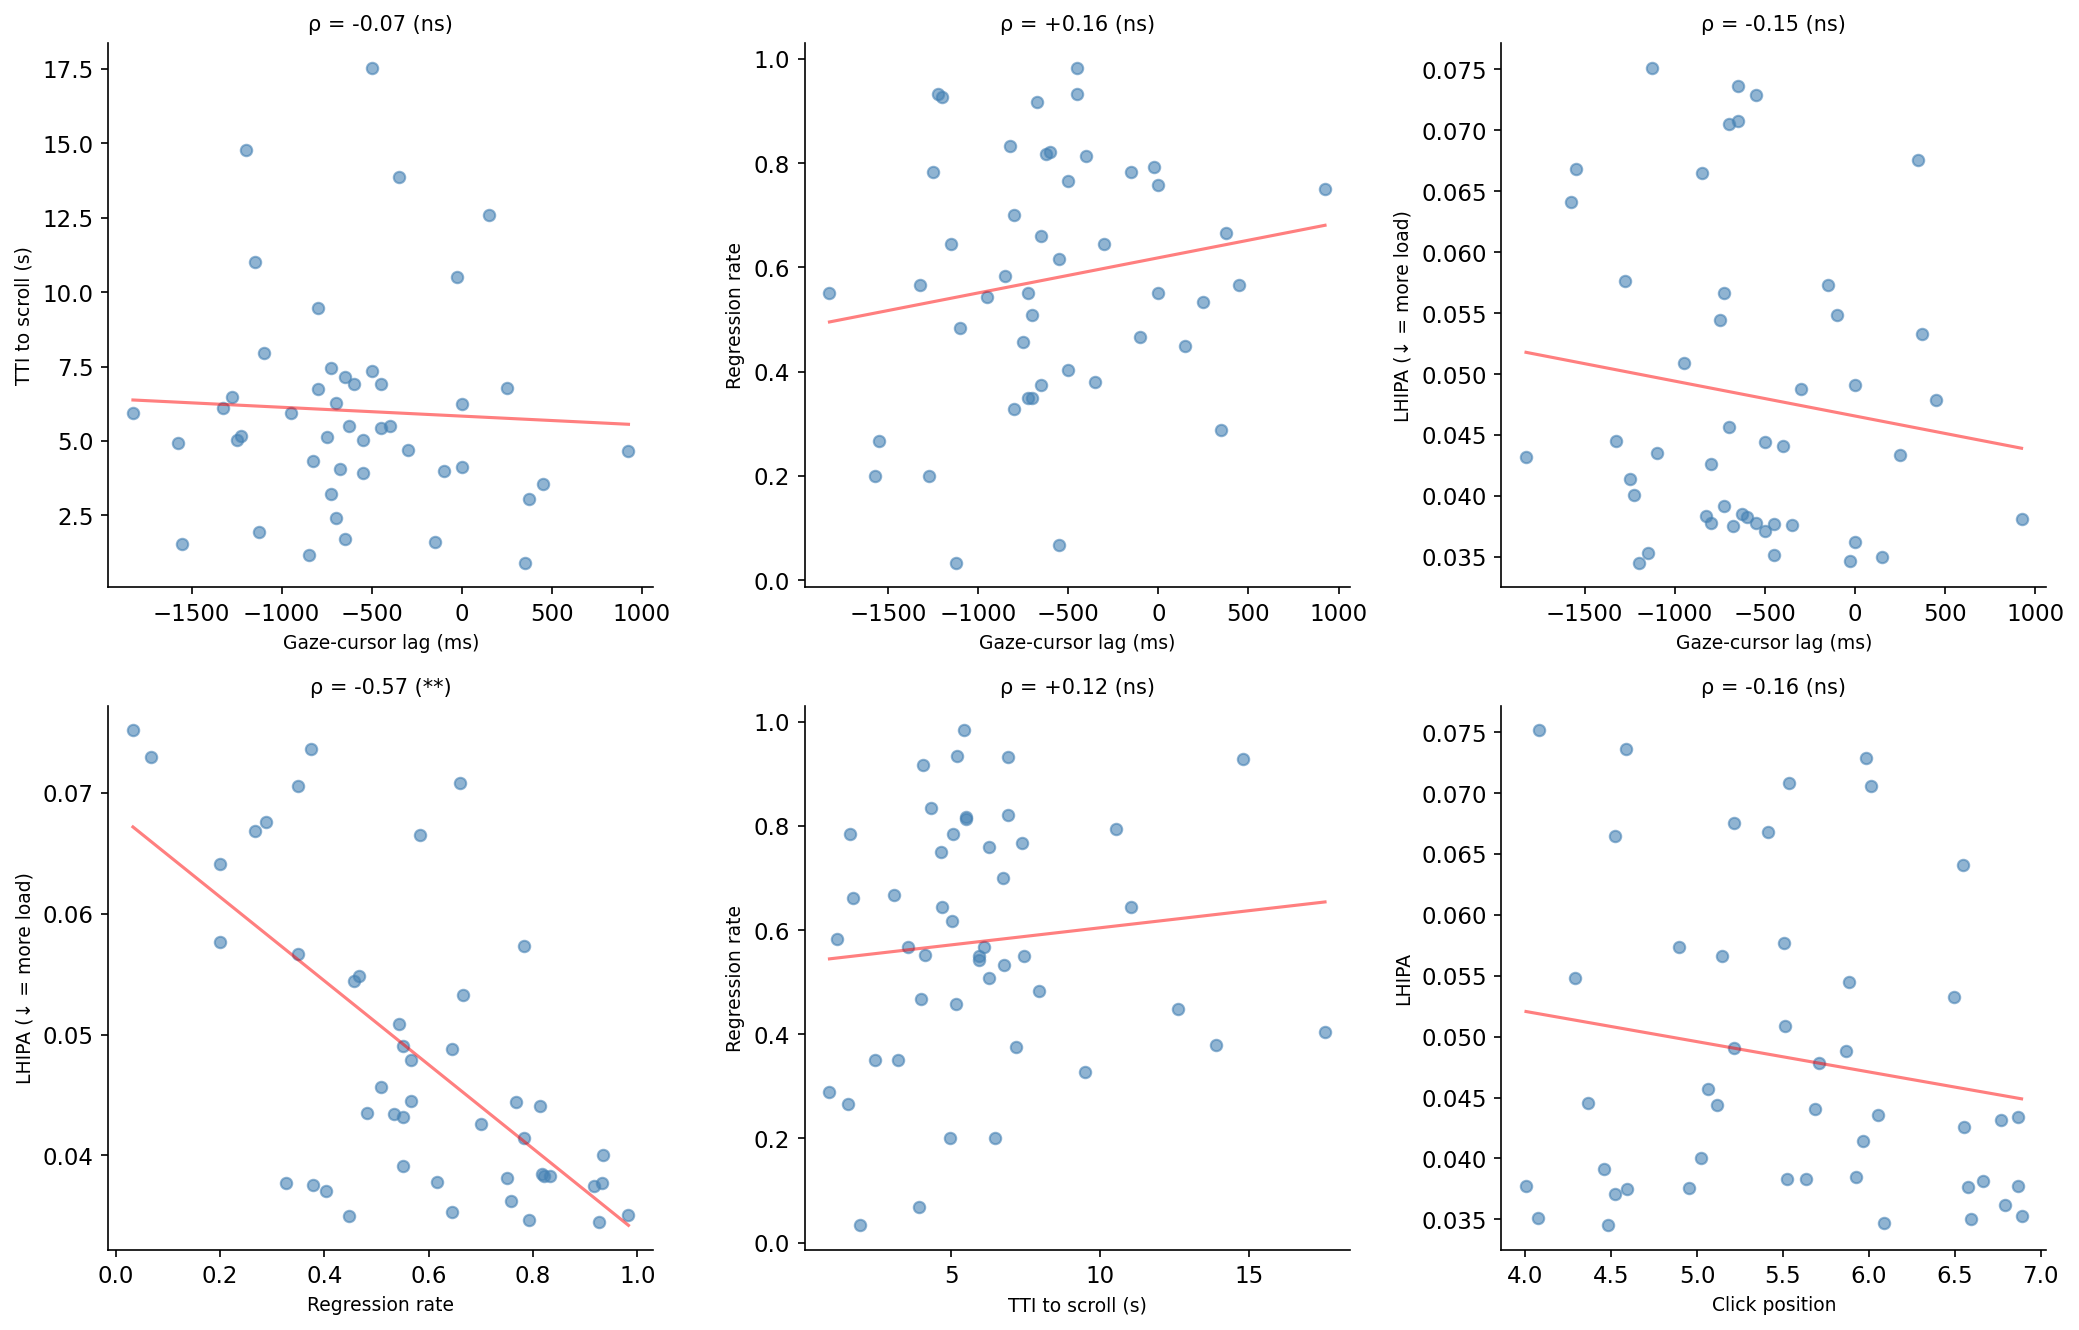

Saved: plot_individual_differences.png


In [6]:
# ── Scatter plots for significant correlations ──────────────────

pairs = [
    ('median_lag_ms', 'median_tti_s', 'Gaze-cursor lag (ms)', 'TTI to scroll (s)', r1, p1),
    ('median_lag_ms', 'regression_rate', 'Gaze-cursor lag (ms)', 'Regression rate', r2, p2),
    ('median_lag_ms', 'mean_lhipa', 'Gaze-cursor lag (ms)', 'LHIPA (↓ = more load)', r3, p3),
    ('regression_rate', 'mean_lhipa', 'Regression rate', 'LHIPA (↓ = more load)', r4, p4),
    ('median_tti_s', 'regression_rate', 'TTI to scroll (s)', 'Regression rate', r5, p5),
    ('mean_click_pos', 'mean_lhipa', 'Click position', 'LHIPA', r6, p6),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (xk, yk, xl, yl, rho, p) in enumerate(pairs):
    ax = axes[i]
    x = np.array([complete[pid][xk] for pid in pids])
    y = np.array([complete[pid][yk] for pid in pids])
    valid = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[valid], y[valid], alpha=0.6, s=30, color='steelblue')
    
    # Trend line
    if valid.sum() >= 5:
        z = np.polyfit(x[valid], y[valid], 1)
        xline = np.linspace(np.min(x[valid]), np.max(x[valid]), 50)
        ax.plot(xline, np.polyval(z, xline), 'r-', alpha=0.5)
    
    sig = '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlabel(xl, fontsize=9)
    ax.set_ylabel(yl, fontsize=9)
    ax.set_title(f'ρ = {rho:+.2f} ({sig})', fontsize=10)

plt.tight_layout()
plt.savefig('plot_individual_differences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_individual_differences.png')

Split-half reliability of gaze-cursor lag:
  r = 0.721, p = 0.0000, n = 46 participants
  Spearman-Brown corrected: 0.838
  (> 0.7 = acceptable reliability as individual difference measure)


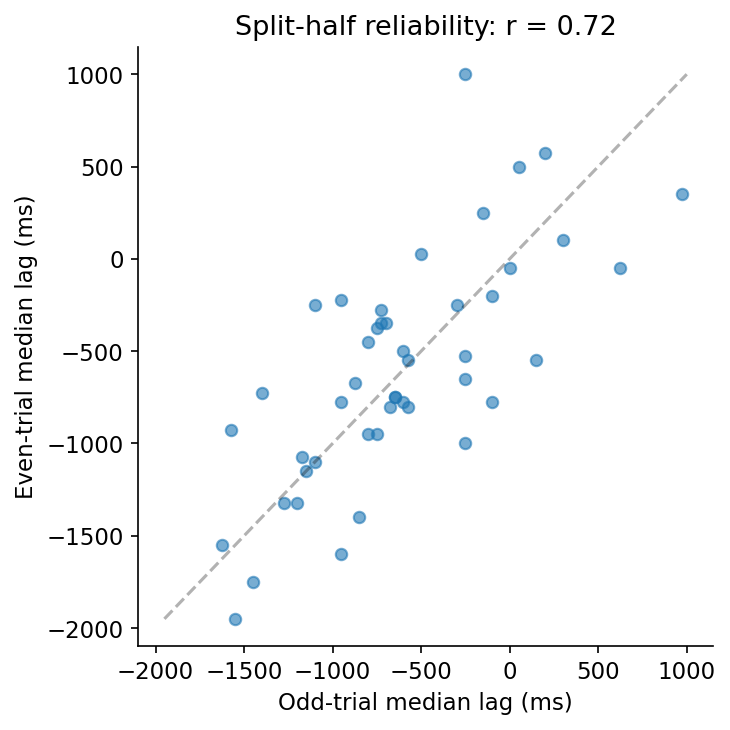

In [7]:
# ── Within-participant stability (ICC proxy) ───────────────────
# For gaze-cursor lag: is it a stable trait or state-dependent?

# Split each participant's trials into odd/even halves
odd_medians, even_medians = [], []
for pid in pids:
    trials_with_lag = [t for t in by_pid[pid] if t['lag_ms'] is not None]
    if len(trials_with_lag) < 10: continue
    odd = [t['lag_ms'] for i, t in enumerate(trials_with_lag) if i % 2 == 1]
    even = [t['lag_ms'] for i, t in enumerate(trials_with_lag) if i % 2 == 0]
    odd_medians.append(np.median(odd))
    even_medians.append(np.median(even))

odd_medians = np.array(odd_medians)
even_medians = np.array(even_medians)

if len(odd_medians) >= 10:
    split_half_r, split_half_p = stats.pearsonr(odd_medians, even_medians)
    print(f'Split-half reliability of gaze-cursor lag:')
    print(f'  r = {split_half_r:.3f}, p = {split_half_p:.4f}, n = {len(odd_medians)} participants')
    print(f'  Spearman-Brown corrected: {2*split_half_r/(1+split_half_r):.3f}')
    print(f'  (> 0.7 = acceptable reliability as individual difference measure)')
    
    plt.figure(figsize=(5, 5))
    plt.scatter(odd_medians, even_medians, alpha=0.6, s=30)
    lims = [min(odd_medians.min(), even_medians.min()), max(odd_medians.max(), even_medians.max())]
    plt.plot(lims, lims, 'k--', alpha=0.3)
    plt.xlabel('Odd-trial median lag (ms)')
    plt.ylabel('Even-trial median lag (ms)')
    plt.title(f'Split-half reliability: r = {split_half_r:.2f}')
    plt.tight_layout()
    plt.savefig('plot_lag_split_half.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Not enough participants with ≥10 trials for split-half: {len(odd_medians)}')

## Summary

If the key correlations are significant, it suggests a coherent individual-differences dimension:

**Processing speed / deliberation trait:**
- Faster gaze-cursor lag → faster TTI → lower regression rate → shallower click → lower cognitive load
- = "satisficer" profile

**Slower / more deliberate:**
- Longer lag → slower TTI → more regressions → deeper (or higher) click → more cognitive load
- = "optimizer" profile

The gaze-cursor lag would be a third independent measure of this dimension, alongside TTI and regression rate — converging evidence from motor, temporal, and behavioral signals.

### Key Measures

| Measure | Definition | Units | Interpretation |
|---------|-----------|-------|----------------|
| Gaze-cursor lag | Per-participant median temporal offset (scroll-corrected cross-correlation) | ms | Motor timing dimension; negative = gaze leads |
| TTI to first scroll | Per-participant median time from page load to first scroll | ms | Temporal behavior dimension; proxy for processing speed |
| Regression rate | Per-participant fraction of trials with scroll regressions | % | Behavioral strategy dimension; satisfice vs optimize |
| Mean LHIPA | Per-participant average cognitive load index | ratio | Cognitive load dimension; lower = more effortful processing |
| Mean click position | Per-participant average rank of clicked result | rank | Outcome measure; deeper = more exploration |


## 11.5 Cursor chattiness as a second motor factor

The individual-differences panel above characterizes the **timing** dimension of motor coordination (gaze–cursor lag). NB11.5 adds a **volume** dimension: per-participant cursor activity traits computed from the raw `mousemove`-family event stream. The two axes are empirically orthogonal — they should be analyzed together rather than collapsed.

Four chattiness measures (see `11_5_chattiness_traits.ipynb` for derivation):

| Measure | Definition |
|---|---|
| `events_per_sec` | cursor position samples per second |
| `path_per_sec` | total 2D euclidean path length / duration |
| `dir_changes_per_sec` | sign flips on Δx or Δy per second |
| `active_fraction` | fraction of 100 ms bins with a position change |

All four are high-reliability individual-differences traits (split-half *r* ≥ 0.966).

In [8]:
# ── Merge chattiness into participant_dvs ──────────────────────

with open('chattiness_per_participant.json') as f:
    chat = json.load(f)

chat_dvs = chat['participants']
MEASURES = chat['measures']

merged = 0
for pid, d in participant_dvs.items():
    if pid in chat_dvs:
        for m in MEASURES:
            d[m] = chat_dvs[pid][m]
        merged += 1

print(f'Merged chattiness into {merged}/{len(participant_dvs)} participants')
print(f'Chattiness measures: {MEASURES}')

Merged chattiness into 47/47 participants
Chattiness measures: ['events_per_sec', 'path_per_sec', 'dir_changes_per_sec', 'active_fraction']


### 11.5a Orthogonality: chattiness vs the NB11 panel

Per-participant Spearman correlations between each chattiness measure and each NB11 panel measure. The key test is **chattiness × gaze–cursor lag**: if that is null, chattiness is operationally a *new* motor factor rather than a redundant re-parameterization of the timing trait.

Orthogonality: chattiness × NB11 panel (n = 47 participants)
                            Lag (ms)       TTI (s)Regression rate         LHIPA     Click pos     Fixations
events_per_sec               +0.03         -0.53*        -0.45*        +0.55*        -0.12         -0.59* 
path_per_sec                 +0.19         -0.57*        -0.11         +0.46*        +0.05         -0.48* 
dir_changes_per_sec          +0.28         -0.50*        -0.13         +0.34*        +0.06         -0.41* 
active_fraction              +0.11         -0.50*        -0.38*        +0.43*        -0.06         -0.52* 


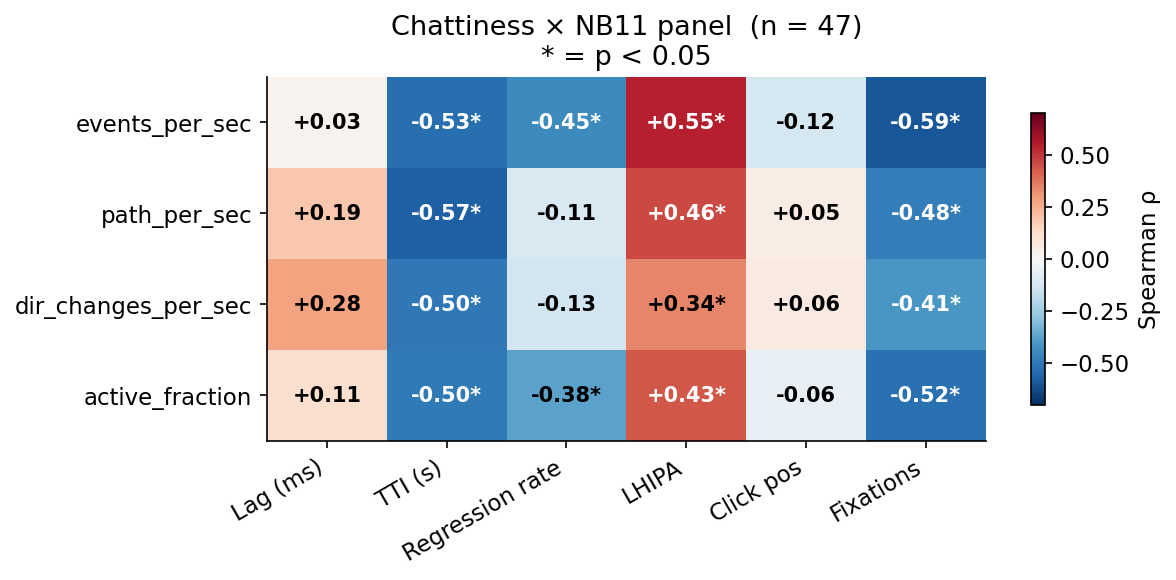

In [9]:
# ── Chattiness × NB11 panel orthogonality matrix ────────────────

nb11_keys = ['median_lag_ms', 'median_tti_s', 'regression_rate',
             'mean_lhipa', 'mean_click_pos', 'mean_fixations']
nb11_labels = ['Lag (ms)', 'TTI (s)', 'Regression rate',
               'LHIPA', 'Click pos', 'Fixations']

shared = [pid for pid in sorted(participant_dvs)
          if all(m in participant_dvs[pid] for m in MEASURES)]
n = len(shared)

rho_matrix = np.full((len(MEASURES), len(nb11_keys)), np.nan)
p_matrix = np.full((len(MEASURES), len(nb11_keys)), np.nan)

for i, m in enumerate(MEASURES):
    chat_vals = np.array([participant_dvs[p][m] for p in shared])
    for j, k in enumerate(nb11_keys):
        other = np.array([participant_dvs[p].get(k, np.nan) for p in shared], dtype=float)
        v = np.isfinite(other)
        if v.sum() < 10:
            continue
        rho, p = stats.spearmanr(chat_vals[v], other[v])
        rho_matrix[i, j] = rho
        p_matrix[i, j] = p

# Text table
print(f'Orthogonality: chattiness × NB11 panel (n = {n} participants)')
print(f'{"":<22s}' + ''.join(f'{lab:>14s}' for lab in nb11_labels))
for i, m in enumerate(MEASURES):
    row = f'{m:<22s}'
    for j in range(len(nb11_keys)):
        rho = rho_matrix[i, j]
        sig = '*' if p_matrix[i, j] < 0.05 else ' '
        row += f'{rho:>+12.2f}{sig} '
    print(row)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(rho_matrix, cmap='RdBu_r', vmin=-0.7, vmax=0.7, aspect='auto')
ax.set_xticks(range(len(nb11_keys)))
ax.set_xticklabels(nb11_labels, rotation=30, ha='right')
ax.set_yticks(range(len(MEASURES)))
ax.set_yticklabels(MEASURES)
for i in range(len(MEASURES)):
    for j in range(len(nb11_keys)):
        if np.isfinite(rho_matrix[i, j]):
            sig = '*' if p_matrix[i, j] < 0.05 else ''
            ax.text(j, i, f'{rho_matrix[i, j]:+.2f}{sig}',
                    ha='center', va='center',
                    color='white' if abs(rho_matrix[i, j]) > 0.4 else 'black',
                    fontsize=10, weight='bold')
plt.colorbar(im, ax=ax, label='Spearman ρ', shrink=0.8)
ax.set_title(f'Chattiness × NB11 panel  (n = {n})\n* = p < 0.05')
plt.tight_layout()
plt.savefig('plot_chattiness_nb11_orthogonality.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.5b Interpretation — the two-factor motor structure

| Relationship | Result |
|---|---|
| **Chattiness × gaze–cursor lag** | *ρ* = +0.03 to +0.28, all *p* > 0.06 (**orthogonal**) |
| Chattiness × TTI to scroll | *ρ* = −0.50 to −0.57, *p* < 0.001 (chatty = faster) |
| Chattiness × LHIPA | *ρ* = +0.34 to +0.55, *p* < 0.05 (chatty = lower cognitive load) |
| Chattiness × fixations/trial | *ρ* = −0.41 to −0.59, *p* < 0.01 (chatty = fewer fixations) |
| Chattiness × regression rate | *ρ* = −0.11 to −0.45 (mixed; `events_per_sec` and `active_fraction` significant) |
| Chattiness × click position | *ρ* = −0.12 to +0.06, null |

**The motor coordination panel is two-factor, not one.**

- **Factor 1 — Timing:** gaze–cursor lag (NB11 original). Negative lag indicates gaze leads cursor. Median across AdSERP participants: −650 ms, close to Huang et al. 2012's −700 ms.
- **Factor 2 — Volume / deliberation:** cursor chattiness. High chatter co-occurs with the satisficer profile (fast TTI, fewer fixations, lower cognitive load). Low chatter co-occurs with the optimizer profile.

These two factors are empirically independent. A user can have tight gaze–cursor timing and still park the cursor (tight timing, low volume) — an "observer" profile. A user can have loose timing and chatter constantly (loose timing, high volume) — a "fidgeter" profile. The 2×2 structure is a richer individual-differences model than the collapsed single-dimension strategy.

The CIKM click-prediction model (NB21, M3) is robust across both factors: LOSO AUC is flat across chattiness terciles (§4.3) and across the full range of gaze–cursor lag. This is a meaningful robustness claim because the two factors separate orthogonally — the null across chattiness is not inherited from the null across lag.